# 03 - Entrenamiento y evaluación inicial de modelos

## Predicción del riesgo de rotura de stock en un entorno logístico

En este notebook entreno y comparo varios modelos de clasificación binaria para predecir `stockout_risk` a partir del dataset generado en el notebook de ingeniería de características.

Para que la evaluación se parezca a una situación real:

- respeto el orden temporal de los datos;
- excluyo variables futuras o utilizadas para construir el target;
- utilizo un modelo sencillo como baseline;
- comparo modelos lineales y modelos basados en árboles;
- calculo varias métricas de clasificación;
- guardo los modelos, predicciones, métricas y gráficos.

> **Alcance del proyecto:** el target es sintético porque el dataset original no contiene inventario real ni roturas observadas. Por tanto, interpreto los resultados como la capacidad para detectar el riesgo definido en la simulación y no como una validación sobre roturas de stock reales.


## 1. Librerías y configuración

### ¿Por qué preparo estas librerías y parámetros?

En esta primera celda importo las librerías que necesito para entrenar, evaluar y guardar los modelos. Uso herramientas de `scikit-learn` para la mayor parte del proceso y añado XGBoost como modelo de boosting.

También fijo algunos valores que voy a reutilizar durante todo el notebook, como la semilla aleatoria, el nombre del target, el porcentaje reservado para test y el umbral inicial de clasificación.

Fijo `RANDOM_STATE = 42` para poder repetir los resultados. Sin una semilla fija, algunos modelos podrían producir resultados ligeramente distintos en cada ejecución.

Podría haber instalado XGBoost directamente desde el notebook si no estuviera disponible, pero prefiero mostrar un error claro. De esta forma, la instalación de librerías queda controlada desde el entorno o desde `requirements.txt`.


In [1]:
# Importo las librerías y defino los parámetros que voy a reutilizar durante el entrenamiento.
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost no está instalado. Ejecuta: python -m pip install xgboost"
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42
TARGET = "stockout_risk"
TEST_SIZE = 0.20
DEFAULT_THRESHOLD = 0.50

## 2. Rutas reproducibles

En esta sección preparo las rutas que utilizaré durante el entrenamiento. Mi objetivo es que el notebook pueda ejecutarse en otro equipo sin depender de rutas específicas de mi ordenador.


### ¿Por qué localizo automáticamente la raíz del proyecto?

En esta celda busco la carpeta principal del proyecto para construir las rutas de datos, modelos, métricas, predicciones y gráficos.

Lo hago así para no depender de una ruta escrita manualmente en mi ordenador. Esto facilita que el proyecto pueda ejecutarse desde otro equipo o desde otra ubicación.

También creo las carpetas de salida si todavía no existen. Uso `exist_ok=True` para que no se produzca un error cuando ya están creadas.

La alternativa más sencilla sería usar rutas como `../data/processed/`, pero podrían fallar dependiendo de la carpeta desde la que se ejecute el notebook.


In [2]:
# Localizo la raíz del proyecto y preparo las carpetas donde guardaré los resultados.
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, current.parent]

    for candidate in candidates:
        if (candidate / "data").exists() or (candidate / "notebooks").exists():
            return candidate

    return current.parent if current.name.lower() == "notebooks" else current


PROJECT_ROOT = find_project_root()
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "stockout_dataset.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures" / "model_training"
METRICS_DIR = OUTPUT_DIR / "metrics"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Dataset procesado:", PROCESSED_DATA_PATH)

Raíz del proyecto: C:\Users\lloro\Documents\GitHub\TFE_PROYECTO1
Dataset procesado: C:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\data\processed\stockout_dataset.csv


## 3. Carga y validación del dataset

Cargo el dataset generado en el notebook anterior y compruebo que contiene la información mínima necesaria para entrenar los modelos.


### ¿Por qué valido el dataset antes de entrenar?

Antes de crear los modelos compruebo que el archivo procesado existe y que contiene las columnas mínimas que necesito.

También verifico que el dataset no esté vacío, que el target no tenga valores nulos y que solo contenga las clases 0 y 1. Estas comprobaciones me permiten detectar errores procedentes del notebook anterior antes de comenzar un entrenamiento que puede tardar varios minutos.

Finalmente, ordeno los datos por fecha, tienda y producto. El orden temporal es importante porque después voy a separar los datos históricos de los datos más recientes.

Una alternativa sería dejar que el entrenamiento falle cuando encuentre un problema, pero los mensajes serían menos claros y sería más difícil saber de dónde viene el error.


In [3]:
# Compruebo que el dataset tiene la estructura necesaria antes de comenzar a entrenar.
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra {PROCESSED_DATA_PATH}. "
        "Ejecuta primero 02_feature_engineering_revisado.ipynb."
    )

df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=["date"])

required_columns = {"date", TARGET}
missing_required = required_columns.difference(df.columns)

if missing_required:
    raise ValueError(f"Faltan columnas obligatorias: {sorted(missing_required)}")

if df.empty:
    raise ValueError("El dataset procesado está vacío.")

if df[TARGET].isna().any():
    raise ValueError("El target contiene valores nulos.")

if not set(df[TARGET].unique()).issubset({0, 1}):
    raise ValueError("El target debe ser binario y contener únicamente 0 y 1.")

df = df.sort_values(["date"] + [c for c in ["store_id", "item_id"] if c in df.columns]).reset_index(drop=True)

print("Dimensiones:", df.shape)
print("Periodo:", df["date"].min().date(), "→", df["date"].max().date())
display(df.head())

Dimensiones: (4472500, 56)
Periodo: 2019-01-31 → 2023-12-24


,date,store_id,item_id,sales,price,promo,weekday,month,year,quarter,week,day,is_weekend,weekday_sin,weekday_cos,month_sin,month_cos,week_sin,week_cos,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_min_7,rolling_max_7,trend_7_30,trend_ratio_7_30,demand_cv_30,sales_change_1d,sales_change_7d,sales_ratio_7d,rolling_price_mean_30,price_vs_mean_30,price_ratio_mean_30,promo_lag_1,promo_change,promo_days_last_7,lead_time_days,coverage_days,stock_estimated,safety_stock,future_sales_d1,future_sales_d2,future_sales_d3,future_sales_d4,future_sales_d5,future_sales_d6,future_sales_d7,future_demand_lead_time,future_demand_7d,stockout_risk
0,2019-01-31,store_1,item_1,50,21.3000,0,3,1,2019,1,5,31,0,0.4339,-0.9010,0.0000,1.0000,0.4647,0.8855,57.0000,40.0000,46.0000,41.0000,42.7143,42.1429,42.7667,7.4098,6.2515,34.0000,57.0000,-0.0524,0.9988,0.1462,-7.0000,10.0000,1.2500,21.0160,0.2840,1.0135,0.0000,0,0.0000,2,1,42.7667,14.5861,41.0000,34.0000,34.0000,64.0000,54.0000,58.0000,53.0000,75.0000,338.0000,1
1,2019-01-31,store_1,item_10,36,16.4700,1,3,1,2019,1,5,31,0,0.4339,-0.9010,0.0000,1.0000,0.4647,0.8855,44.0000,24.0000,24.0000,18.0000,21.8571,22.9286,21.3667,11.1569,6.9207,11.0000,44.0000,0.4905,1.0230,0.3239,-8.0000,12.0000,1.5000,20.1780,-3.7080,0.8162,1.0000,0,1.0000,5,8,170.9333,25.5368,22.0000,25.0000,17.0000,18.0000,22.0000,23.0000,23.0000,104.0000,150.0000,0
2,2019-01-31,store_1,item_11,26,65.2500,0,3,1,2019,1,5,31,0,0.4339,-0.9010,0.0000,1.0000,0.4647,0.8855,29.0000,21.0000,24.0000,27.0000,21.5714,22.2857,22.6333,6.8034,5.6598,14.0000,32.0000,-1.0619,0.9531,0.2501,-3.0000,5.0000,1.2381,64.8150,0.4350,1.0067,0.0000,0,0.0000,2,4,90.5333,13.2055,26.0000,20.0000,22.0000,23.0000,26.0000,25.0000,25.0000,46.0000,167.0000,0
3,2019-01-31,store_1,item_12,20,60.8800,0,3,1,2019,1,5,31,0,0.4339,-0.9010,0.0000,1.0000,0.4647,0.8855,26.0000,23.0000,19.0000,13.0000,22.5714,21.4286,19.5000,3.5051,5.4819,17.0000,26.0000,3.0714,1.1575,0.2811,-6.0000,-3.0000,0.8696,58.8500,2.0300,1.0345,0.0000,0,2.0000,4,1,19.5000,18.0904,15.0000,14.0000,14.0000,23.0000,26.0000,25.0000,20.0000,66.0000,137.0000,1
4,2019-01-31,store_1,item_13,37,68.1900,0,3,1,2019,1,5,31,0,0.4339,-0.9010,0.0000,1.0000,0.4647,0.8855,47.0000,43.0000,39.0000,41.0000,38.2857,37.0000,37.1000,6.7011,7.9236,27.0000,47.0000,1.1857,1.0320,0.2136,-10.0000,-6.0000,0.8605,67.2807,0.9093,1.0135,0.0000,0,0.0000,3,8,296.8000,22.6495,32.0000,33.0000,33.0000,39.0000,45.0000,49.0000,45.0000,98.0000,276.0000,0


## 4. Calidad mínima y distribución del target

Antes de entrenar, reviso el estado general de los datos y la proporción de casos con y sin riesgo.


### ¿Por qué reviso la calidad y la distribución del target?

En esta celda creo un resumen sencillo con el tamaño del dataset, los duplicados, los valores ausentes, el periodo analizado y la proporción de casos positivos.

Me interesa especialmente conocer la distribución del target porque un problema muy desbalanceado puede hacer que métricas como accuracy resulten engañosas.

Guardo estas tablas en CSV para poder utilizarlas más adelante en el README y para conservar una evidencia de los datos con los que se entrenaron los modelos.

Podría limitarme a mostrar `value_counts()`, pero prefiero guardar también la proporción y el resumen general para que el análisis sea reproducible.


In [4]:
# Resumo la calidad de los datos y reviso cómo se distribuye la variable objetivo.
quality_summary = pd.DataFrame({
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "duplicate_rows": [int(df.duplicated().sum())],
    "missing_values": [int(df.isna().sum().sum())],
    "positive_rate": [float(df[TARGET].mean())],
    "min_date": [df["date"].min()],
    "max_date": [df["date"].max()],
})

display(quality_summary)

target_distribution = pd.concat(
    [
        df[TARGET].value_counts().sort_index().rename("count"),
        df[TARGET].value_counts(normalize=True).sort_index().rename("proportion"),
    ],
    axis=1,
)

display(target_distribution)
quality_summary.to_csv(METRICS_DIR / "training_data_quality.csv", index=False)
target_distribution.to_csv(METRICS_DIR / "training_target_distribution.csv")

,rows,columns,duplicate_rows,missing_values,positive_rate,min_date,max_date
0,4472500,56,0,1034,0.5356,2019-01-31,2023-12-24


,count,proportion
stockout_risk,,
0,2076998,0.4644
1,2395502,0.5356


## 5. Control de fuga de información

En esta sección identifico las columnas que contienen información futura o que participaron directamente en la construcción del target. Las conservo para análisis posteriores, pero no las utilizo como entrada de los modelos.


### ¿Por qué identifico las columnas con riesgo de fuga de información?

En este proyecto algunas variables se han utilizado para construir el target sintético. Si las usara también como entrada del modelo, este podría aprender directamente la regla con la que se creó la etiqueta.

Por eso identifico columnas relacionadas con demanda futura, stock estimado, stock de seguridad y cobertura. No las elimino del dataset completo porque pueden ser útiles para el análisis posterior, pero no deben formar parte de las variables predictoras.

Una alternativa sería borrar estas columnas definitivamente. No lo hago porque en el notebook de explicabilidad y negocio pueden ayudarme a entender los resultados simulados.


In [5]:
# Identifico las columnas que no debo utilizar porque contienen información futura o directa del target.
forbidden_exact = {
    TARGET,
    "future_demand_lead_time",
    "future_demand_7d",
    "stock_estimated",
    "safety_stock",
    "coverage_days",
}

forbidden_prefixes = ("future_sales_",)

detected_forbidden = sorted(
    col for col in df.columns
    if col in forbidden_exact or col.startswith(forbidden_prefixes)
)

print("Columnas excluidas por leakage o uso analítico:")
print(detected_forbidden)

Columnas excluidas por leakage o uso analítico:
['coverage_days', 'future_demand_7d', 'future_demand_lead_time', 'future_sales_d1', 'future_sales_d2', 'future_sales_d3', 'future_sales_d4', 'future_sales_d5', 'future_sales_d6', 'future_sales_d7', 'safety_stock', 'stock_estimated', 'stockout_risk']


## 6. Selección de variables predictoras

Selecciono únicamente las variables que considero disponibles en el momento en que se realizaría la predicción.


### ¿Por qué selecciono las variables de forma explícita?

En lugar de utilizar automáticamente todas las columnas numéricas, preparo una lista con las features que considero disponibles en el momento de la predicción.

Después compruebo cuáles existen realmente en el dataset, si alguna contiene información futura, si todas son numéricas y si tienen valores nulos.

Esta forma de trabajar me ayuda a controlar exactamente qué información recibe el modelo y evita incluir una columna nueva por error.

La alternativa sería usar algo como `df.select_dtypes()`, pero podría incorporar variables identificadoras o columnas creadas para analizar el target que no deberían utilizarse para entrenar.


In [6]:
# Selecciono de forma controlada las variables que voy a entregar a los modelos.
candidate_features = [
    "sales",
    "price",
    "promo",
    "weekday",
    "month",
    "year",
    "quarter",
    "week",
    "day",
    "is_weekend",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30",
    "rolling_min_7",
    "rolling_max_7",
    "trend_7_30",
    "trend_ratio_7_30",
    "demand_cv_30",
    "sales_change_1d",
    "sales_change_7d",
    "rolling_price_mean_30",
    "price_vs_mean_30",
    "price_ratio_mean_30",
    "promo_lag_1",
    "promo_change",
    "promo_days_last_7",
    "lead_time_days",
]

available_features = [col for col in candidate_features if col in df.columns]
missing_features = [col for col in candidate_features if col not in df.columns]

if not available_features:
    raise ValueError("No se encontró ninguna feature válida.")

leaked_features = [
    col for col in available_features
    if col in forbidden_exact or col.startswith(forbidden_prefixes)
]
if leaked_features:
    raise ValueError(f"Se han incluido features con leakage: {leaked_features}")

non_numeric = [col for col in available_features if not pd.api.types.is_numeric_dtype(df[col])]
if non_numeric:
    raise TypeError(f"Las siguientes features no son numéricas: {non_numeric}")

null_features = df[available_features].isna().sum()
null_features = null_features[null_features > 0]
if not null_features.empty:
    raise ValueError(
        "Existen nulos en las features. Revisa el notebook 02:\n"
        + null_features.to_string()
    )

print(f"Features utilizadas: {len(available_features)}")
print(available_features)

if missing_features:
    print(f"\nFeatures opcionales no encontradas: {len(missing_features)}")
    print(missing_features)

Features utilizadas: 39
['sales', 'price', 'promo', 'weekday', 'month', 'year', 'quarter', 'week', 'day', 'is_weekend', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30', 'rolling_min_7', 'rolling_max_7', 'trend_7_30', 'trend_ratio_7_30', 'demand_cv_30', 'sales_change_1d', 'sales_change_7d', 'rolling_price_mean_30', 'price_vs_mean_30', 'price_ratio_mean_30', 'promo_lag_1', 'promo_change', 'promo_days_last_7', 'lead_time_days']


## 7. Partición temporal train/test

Divido los datos por fechas únicas. De esta forma, utilizo las fechas más antiguas para entrenar y las más recientes para evaluar.


### ¿Por qué hago una partición temporal?

Como estoy trabajando con datos ordenados en el tiempo, entreno los modelos con las fechas antiguas y los evalúo con las fechas más recientes.

Uso las fechas únicas para realizar el corte. Así evito que registros del mismo día aparezcan a la vez en train y test.

Este método se parece más a una situación real, donde entrenaría con información histórica para predecir periodos futuros.

Podría utilizar `train_test_split` con mezcla aleatoria, pero eso permitiría que el modelo aprendiera de fechas posteriores para predecir fechas anteriores y ofrecería una evaluación menos realista.


In [7]:
# Separo los datos por fechas para entrenar con el pasado y evaluar con el periodo más reciente.
unique_dates = np.array(sorted(df["date"].dropna().unique()))

if len(unique_dates) < 10:
    raise ValueError("No hay suficientes fechas únicas para una validación temporal fiable.")

split_position = int(np.floor(len(unique_dates) * (1 - TEST_SIZE)))
split_position = min(max(split_position, 1), len(unique_dates) - 1)

test_start_date = pd.Timestamp(unique_dates[split_position])

train_df = df[df["date"] < test_start_date].copy()
test_df = df[df["date"] >= test_start_date].copy()

if train_df.empty or test_df.empty:
    raise ValueError("La partición temporal ha generado un conjunto vacío.")

X_train = train_df[available_features].copy()
y_train = train_df[TARGET].astype(int).copy()
X_test = test_df[available_features].copy()
y_test = test_df[TARGET].astype(int).copy()

if y_train.nunique() < 2 or y_test.nunique() < 2:
    raise ValueError("Train y test deben contener ambas clases.")

split_summary = pd.DataFrame({
    "set": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "start_date": [train_df["date"].min(), test_df["date"].min()],
    "end_date": [train_df["date"].max(), test_df["date"].max()],
    "positive_rate": [y_train.mean(), y_test.mean()],
})

display(split_summary)
split_summary.to_csv(METRICS_DIR / "temporal_split_summary.csv", index=False)

,set,rows,start_date,end_date,positive_rate
0,train,3577500,2019-01-31,2022-12-31,0.5360
1,test,895000,2023-01-01,2023-12-24,0.5339


## 8. Modelos comparados

Comparo cuatro referencias:

1. **Dummy Classifier:** lo utilizo como baseline porque no aprende relaciones entre las variables.
2. **Logistic Regression:** me ofrece un modelo lineal y relativamente fácil de interpretar.
3. **Random Forest:** puede aprender relaciones no lineales mediante varios árboles.
4. **XGBoost:** utiliza boosting y puede capturar interacciones más complejas.

No busco probar todos los algoritmos posibles, sino comparar modelos con comportamientos diferentes.


### ¿Por qué comparo estos cuatro modelos?

Incluyo un Dummy Classifier como referencia mínima. Este modelo no aprende relaciones entre las variables, por lo que me sirve para comprobar si los demás modelos aportan realmente capacidad predictiva.

La regresión logística es un modelo relativamente sencillo e interpretable. Random Forest y XGBoost pueden aprender relaciones no lineales e interacciones más complejas.

También calculo `scale_pos_weight` para que XGBoost tenga en cuenta la proporción entre las dos clases.

Podría probar muchos más algoritmos, pero prefiero comparar pocas opciones que representen enfoques diferentes y explicar correctamente sus resultados.


In [8]:
# Defino un baseline y tres modelos con enfoques diferentes para poder compararlos.
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1.0

models = {
    "Dummy Classifier": DummyClassifier(
        strategy="prior",
        random_state=RANDOM_STATE,
    ),
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=14,
        min_samples_leaf=15,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    ),
}

print("Modelos:", list(models))
print("scale_pos_weight:", round(scale_pos_weight, 4))

Modelos: ['Dummy Classifier', 'Logistic Regression', 'Random Forest', 'XGBoost']
scale_pos_weight: 0.8655


## 9. Función de evaluación

Creo una función común para calcular las mismas métricas en todos los modelos y facilitar su comparación.


### ¿Por qué creo una función de evaluación?

Todos los modelos deben evaluarse con las mismas métricas. Para evitar repetir código, creo una función que recibe los valores reales, las predicciones y las probabilidades.

Calculo accuracy, precision, recall, F1, ROC-AUC y PR-AUC. Además, extraigo los valores de la matriz de confusión y el número de alertas generadas.

No me quedo únicamente con accuracy porque podría ocultar un mal comportamiento sobre la clase positiva.

Podría usar directamente `classification_report`, pero esta función me permite guardar todas las métricas en una tabla común y comparar los modelos con facilidad.


In [9]:
# Creo una función común para evaluar todos los modelos con los mismos criterios.
def evaluate_predictions(y_true, y_pred, y_proba):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics.update({
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "alerts": int((y_pred == 1).sum()),
        "alert_rate": float((y_pred == 1).mean()),
    })

    return metrics

## 10. Entrenamiento

Entreno todos los modelos con los mismos conjuntos de datos. En esta fase utilizo el umbral estándar 0,50 para mantener una comparación inicial común.


### ¿Por qué clono y entreno cada modelo de la misma forma?

Recorro el diccionario de modelos para aplicar exactamente el mismo proceso a todos: entrenar, calcular probabilidades, convertirlas en clases y medir el resultado.

Uso `clone()` para crear una copia limpia de cada estimador. También mido el tiempo de entrenamiento porque el coste computacional puede ser relevante al comparar modelos.

En esta fase utilizo el umbral 0,50 para todos. Lo mantengo fijo porque primero quiero comparar los modelos en igualdad de condiciones. El umbral se optimizará después según criterios de negocio.

Una alternativa sería ajustar cada umbral durante el entrenamiento, pero mezclaría la comparación del modelo con la decisión operativa.


In [10]:
# Entreno cada modelo, calculo sus probabilidades y guardo sus resultados.
results = []
predictions = {}
trained_models = {}

for model_name, estimator in models.items():
    print(f"Entrenando {model_name}...")
    model = clone(estimator)

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start_time

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= DEFAULT_THRESHOLD).astype(int)

    row = {
        "model": model_name,
        **evaluate_predictions(y_test, y_pred, y_proba),
        "training_seconds": training_seconds,
        "threshold": DEFAULT_THRESHOLD,
    }

    results.append(row)
    predictions[model_name] = {"y_pred": y_pred, "y_proba": y_proba}
    trained_models[model_name] = model

    print(
        f"F1={row['f1_score']:.4f} | Recall={row['recall']:.4f} | "
        f"PR-AUC={row['pr_auc']:.4f} | Tiempo={training_seconds:.2f}s"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(["pr_auc", "f1_score"], ascending=False)
    .reset_index(drop=True)
)

display(results_df)
results_df.to_csv(METRICS_DIR / "model_metrics.csv", index=False)

Entrenando Dummy Classifier...
F1=0.6961 | Recall=1.0000 | PR-AUC=0.5339 | Tiempo=0.51s
Entrenando Logistic Regression...
F1=0.7580 | Recall=0.7418 | PR-AUC=0.8499 | Tiempo=39.66s
Entrenando Random Forest...
F1=0.7780 | Recall=0.7501 | PR-AUC=0.8851 | Tiempo=2044.47s
Entrenando XGBoost...
F1=0.8006 | Recall=0.7761 | PR-AUC=0.8990 | Tiempo=103.92s


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,alerts,alert_rate,training_seconds,threshold
0,XGBoost,0.7937,0.8267,0.7761,0.8006,0.8843,0.8990,339479,77718,106959,370844,448562,0.5012,103.9211,0.5000
1,Random Forest,0.7715,0.8082,0.7501,0.7780,0.8662,0.8851,332143,85054,119425,358378,443432,0.4955,2044.4744,0.5000
2,Logistic Regression,0.7472,0.7750,0.7418,0.7580,0.8285,0.8499,314281,102916,123350,354453,457369,0.5110,39.6582,0.5000
3,Dummy Classifier,0.5339,0.5339,1.0000,0.6961,0.5000,0.5339,0,417197,0,477803,895000,1.0000,0.5109,0.5000


## 11. Comparación frente al baseline

Comparo las métricas de cada modelo con las del Dummy Classifier para comprobar si realmente aportan capacidad predictiva.


### ¿Por qué comparo los modelos con el baseline?

Una métrica aislada puede parecer aceptable, pero necesito saber si mejora realmente una estrategia ingenua.

Por eso resto las métricas del Dummy Classifier a las de cada modelo. Un valor positivo indica que el modelo supera al baseline en esa medida.

Esta comparación me ayuda a justificar si el aprendizaje automático está aportando algo útil.

Podría comparar solo el mejor modelo con el baseline, pero mantener todos los resultados permite ver qué enfoques mejoran y cuáles no.


In [11]:
# Mido cuánto mejora cada modelo respecto a una estrategia que no aprende de las variables.
baseline_row = results_df.loc[results_df["model"] == "Dummy Classifier"].iloc[0]
comparison_df = results_df.copy()

for metric in ["f1_score", "roc_auc", "pr_auc", "recall", "precision"]:
    comparison_df[f"{metric}_vs_baseline"] = comparison_df[metric] - baseline_row[metric]

display(comparison_df)
comparison_df.to_csv(METRICS_DIR / "model_comparison_vs_baseline.csv", index=False)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,alerts,alert_rate,training_seconds,threshold,f1_score_vs_baseline,roc_auc_vs_baseline,pr_auc_vs_baseline,recall_vs_baseline,precision_vs_baseline
0,XGBoost,0.7937,0.8267,0.7761,0.8006,0.8843,0.8990,339479,77718,106959,370844,448562,0.5012,103.9211,0.5000,0.1045,0.3843,0.3651,-0.2239,0.2929
1,Random Forest,0.7715,0.8082,0.7501,0.7780,0.8662,0.8851,332143,85054,119425,358378,443432,0.4955,2044.4744,0.5000,0.0819,0.3662,0.3513,-0.2499,0.2743
2,Logistic Regression,0.7472,0.7750,0.7418,0.7580,0.8285,0.8499,314281,102916,123350,354453,457369,0.5110,39.6582,0.5000,0.0620,0.3285,0.3160,-0.2582,0.2411
3,Dummy Classifier,0.5339,0.5339,1.0000,0.6961,0.5000,0.5339,0,417197,0,477803,895000,1.0000,0.5109,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


## 12. Selección provisional del modelo

Selecciono provisionalmente el modelo con mejor PR-AUC y utilizo F1 como segundo criterio. La decisión definitiva dependerá también del análisis de negocio y de los umbrales.


### ¿Por qué selecciono un modelo provisional?

Ordeno los modelos por PR-AUC y, como segundo criterio, por F1. Excluyo el Dummy Classifier porque solo sirve como referencia.

Llamo provisional a esta selección porque todavía no he estudiado los costes de los falsos positivos, los falsos negativos ni los distintos umbrales.

Guardo el modelo, la lista de features y sus metadatos para poder continuar el análisis en el siguiente notebook sin volver a entrenar.

Podría seleccionar el modelo solo por accuracy o ROC-AUC, pero PR-AUC resulta más útil para estudiar la capacidad de identificar la clase positiva.


In [12]:
# Selecciono y guardo el mejor modelo provisional según las métricas definidas.
eligible_results = results_df[results_df["model"] != "Dummy Classifier"].copy()

best_model_name = eligible_results.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_y_pred = predictions[best_model_name]["y_pred"]
best_y_proba = predictions[best_model_name]["y_proba"]

print("Modelo provisional seleccionado:", best_model_name)
display(eligible_results.iloc[[0]])

joblib.dump(best_model, MODELS_DIR / "best_stockout_model.pkl")

with open(MODELS_DIR / "model_features.json", "w", encoding="utf-8") as file:
    json.dump(available_features, file, ensure_ascii=False, indent=2)

model_metadata = {
    "model_name": best_model_name,
    "selection_metric": "pr_auc",
    "default_threshold": DEFAULT_THRESHOLD,
    "train_start": str(train_df["date"].min().date()),
    "train_end": str(train_df["date"].max().date()),
    "test_start": str(test_df["date"].min().date()),
    "test_end": str(test_df["date"].max().date()),
    "features": available_features,
    "random_state": RANDOM_STATE,
    "target_is_synthetic": True,
}

with open(MODELS_DIR / "model_metadata.json", "w", encoding="utf-8") as file:
    json.dump(model_metadata, file, ensure_ascii=False, indent=2)

Modelo provisional seleccionado: XGBoost


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives,alerts,alert_rate,training_seconds,threshold
0,XGBoost,0.7937,0.8267,0.7761,0.8006,0.8843,0.8990,339479,77718,106959,370844,448562,0.5012,103.9211,0.5000


## 13. Matriz de confusión e informe de clasificación

Analizo con más detalle los aciertos y errores del modelo provisional mediante la matriz de confusión y el informe de clasificación.


### ¿Por qué reviso la matriz de confusión?

La matriz de confusión me permite ver cuántos casos se han clasificado correctamente y qué tipo de errores está cometiendo el modelo.

En este problema me interesan especialmente los falsos negativos, porque representan casos de riesgo que el modelo no detecta.

También genero el informe de clasificación para consultar precision, recall y F1 por clase.

Podría mostrar únicamente las métricas generales, pero la matriz permite interpretar el comportamiento del modelo de una forma más directa.


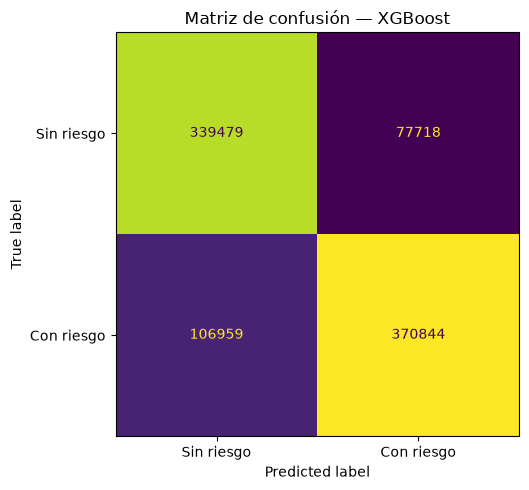

,precision,recall,f1-score,support
Sin riesgo,0.7604,0.8137,0.7862,417197.0000
Con riesgo,0.8267,0.7761,0.8006,477803.0000
accuracy,0.7937,0.7937,0.7937,0.7937
macro avg,0.7936,0.7949,0.7934,895000.0000
weighted avg,0.7958,0.7937,0.7939,895000.0000


In [13]:
# Reviso con más detalle los aciertos y errores del modelo seleccionado.
cm = confusion_matrix(y_test, best_y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sin riesgo", "Con riesgo"],
).plot(ax=ax, values_format="d", colorbar=False)

ax.set_title(f"Matriz de confusión — {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_best_model.png", dpi=160, bbox_inches="tight")
plt.show()

report_df = pd.DataFrame(
    classification_report(
        y_test,
        best_y_pred,
        target_names=["Sin riesgo", "Con riesgo"],
        output_dict=True,
        zero_division=0,
    )
).T

display(report_df)
report_df.to_csv(METRICS_DIR / "classification_report_best_model.csv")

## 14. Curvas ROC y Precision-Recall

Represento estas curvas para comparar el comportamiento de todos los modelos a través de diferentes umbrales.


### ¿Por qué dibujo las curvas ROC y Precision-Recall?

La curva ROC muestra la relación entre verdaderos positivos y falsos positivos para distintos umbrales.

La curva Precision-Recall se centra más en la clase positiva y me permite observar el equilibrio entre detectar más casos y mantener la precisión de las alertas.

Incluyo todos los modelos en los mismos gráficos para poder compararlos visualmente.

Podría quedarme solo con ROC, pero la curva Precision-Recall aporta información especialmente útil cuando la clase positiva tiene más interés para el negocio.


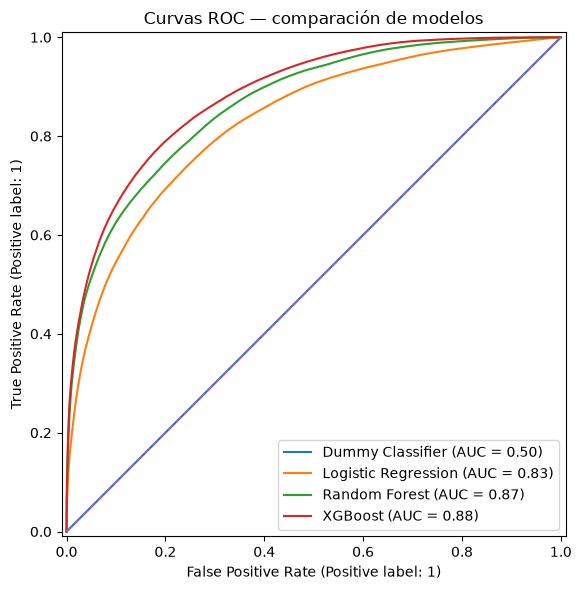

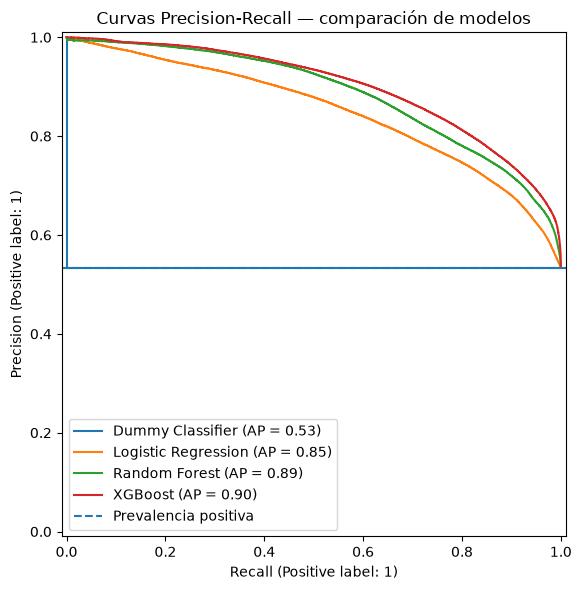

In [14]:
# Comparo visualmente el rendimiento de los modelos para diferentes umbrales.
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, model_info in predictions.items():
    RocCurveDisplay.from_predictions(
        y_test,
        model_info["y_proba"],
        name=model_name,
        ax=ax,
    )
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Curvas ROC — comparación de modelos")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves_models.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for model_name, model_info in predictions.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        model_info["y_proba"],
        name=model_name,
        ax=ax,
    )
ax.axhline(y=y_test.mean(), linestyle="--", label="Prevalencia positiva")
ax.set_title("Curvas Precision-Recall — comparación de modelos")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curves_models.png", dpi=160, bbox_inches="tight")
plt.show()

## 15. Importancia inicial de variables

Obtengo una primera aproximación de las variables más importantes. Considero este resultado orientativo, ya que la explicabilidad detallada se realizará en el siguiente notebook.


### ¿Por qué calculo una importancia inicial de variables?

Quiero obtener una primera idea de qué variables utiliza más el modelo seleccionado.

En la regresión logística tomo el valor absoluto de los coeficientes, ya que las variables han sido estandarizadas. En los modelos de árboles utilizo la importancia interna ofrecida por el estimador.

Esta importancia es orientativa y no explica por sí sola el efecto exacto de cada variable. El análisis más completo se realizará después con técnicas como SHAP.

Podría aplicar SHAP directamente en este notebook, pero prefiero separar el entrenamiento de la explicabilidad para mantener cada fase más ordenada.


,feature,importance,importance_type
0,lead_time_days,0.4271,model_feature_importance
1,sales_lag_14,0.0616,model_feature_importance
2,week_cos,0.0431,model_feature_importance
3,price,0.0407,model_feature_importance
4,weekday_cos,0.0325,model_feature_importance
5,rolling_price_mean_30,0.0312,model_feature_importance
6,sales_lag_1,0.0303,model_feature_importance
7,weekday_sin,0.0287,model_feature_importance
8,sales_lag_7,0.0251,model_feature_importance
9,rolling_mean_30,0.0243,model_feature_importance


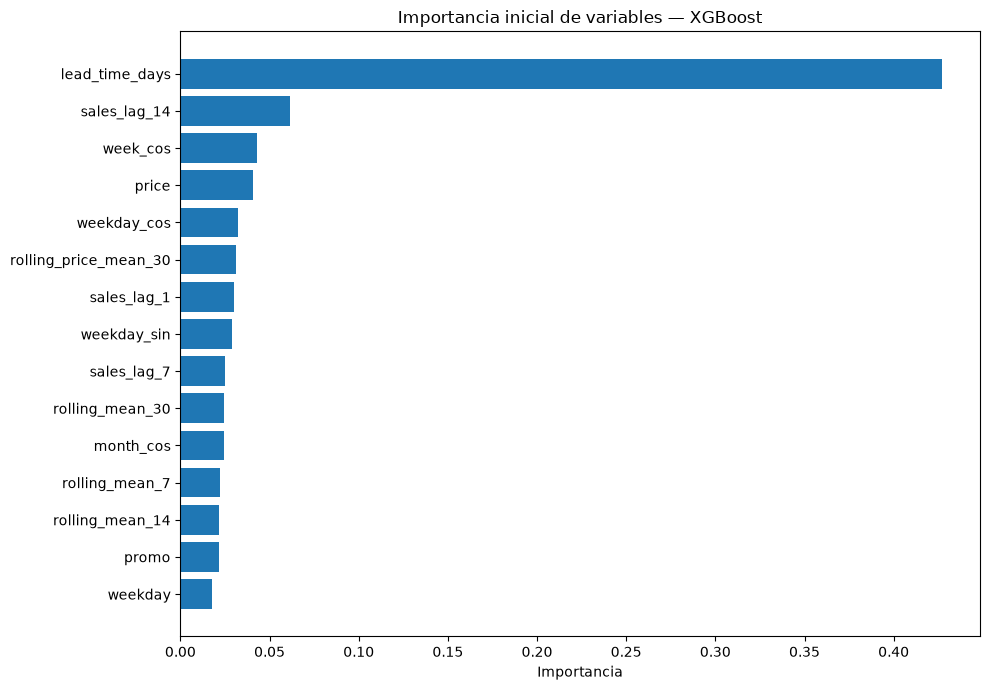

In [15]:
# Obtengo una primera aproximación de las variables más utilizadas por el modelo.
def extract_feature_importance(model, feature_names):
    if isinstance(model, Pipeline):
        final_model = model.named_steps["model"]
        if hasattr(final_model, "coef_"):
            values = np.abs(final_model.coef_[0])
            return values, "absolute_standardized_coefficient"

    if hasattr(model, "feature_importances_"):
        return model.feature_importances_, "model_feature_importance"

    return None, None


importance_values, importance_type = extract_feature_importance(
    best_model,
    available_features,
)

if importance_values is not None:
    importance_df = (
        pd.DataFrame({
            "feature": available_features,
            "importance": importance_values,
            "importance_type": importance_type,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(importance_df.head(20))
    importance_df.to_csv(
        METRICS_DIR / "feature_importance_best_model.csv",
        index=False,
    )

    top = importance_df.head(15).sort_values("importance")
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top["feature"], top["importance"])
    ax.set_title(f"Importancia inicial de variables — {best_model_name}")
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "feature_importance_best_model.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("El modelo seleccionado no ofrece una importancia directa.")

## 16. Exportación de predicciones

Guardo las probabilidades y predicciones del conjunto de test para continuar después con el análisis de umbrales, errores, explicabilidad y métricas de negocio.


### ¿Por qué guardo las probabilidades y no solo las clases?

La probabilidad estimada contiene más información que una predicción final de 0 o 1.

La guardo junto con los identificadores y algunas variables auxiliares porque después la necesitaré para cambiar el umbral, ordenar los casos por riesgo y analizar errores.

También incluyo la predicción obtenida con el umbral 0,50 para conservar el resultado utilizado en esta primera evaluación.

Una alternativa sería volver a cargar el modelo y recalcular todas las probabilidades en el siguiente notebook, pero exportarlas evita repetir trabajo y reduce el riesgo de usar un test diferente.


In [16]:
# Exporto las probabilidades del test para utilizarlas en el análisis posterior.
id_columns = [
    col for col in ["date", "store_id", "item_id"]
    if col in test_df.columns
]

analysis_columns = [
    col for col in [
        "future_demand_lead_time",
        "stock_estimated",
        "safety_stock",
        "coverage_days",
        "lead_time_days",
    ]
    if col in test_df.columns
]

prediction_output = test_df[id_columns + analysis_columns].reset_index(drop=True).copy()
prediction_output["y_true"] = y_test.reset_index(drop=True)
prediction_output["y_pred_threshold_050"] = best_y_pred
prediction_output["y_proba"] = best_y_proba
prediction_output["model"] = best_model_name
prediction_output["dataset_split"] = "test"

predictions_path = PREDICTIONS_DIR / "test_predictions_best_model.csv"
prediction_output.to_csv(predictions_path, index=False)

print("Predicciones guardadas en:", predictions_path)
display(prediction_output.head())

Predicciones guardadas en: C:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\outputs\predictions\test_predictions_best_model.csv


,date,store_id,item_id,future_demand_lead_time,stock_estimated,safety_stock,coverage_days,lead_time_days,y_true,y_pred_threshold_050,y_proba,model,dataset_split
0,2023-01-01,store_1,item_1,107.0000,44.5000,25.0452,1,2,1,1,0.5898,XGBoost,test
1,2023-01-01,store_1,item_10,139.0000,177.0667,23.2916,8,5,0,1,0.7308,XGBoost,test
2,2023-01-01,store_1,item_11,53.0000,94.8000,12.0717,4,2,0,0,0.1818,XGBoost,test
3,2023-01-01,store_1,item_12,123.0000,20.9333,20.3966,1,4,1,1,0.6410,XGBoost,test
4,2023-01-01,store_1,item_13,140.0000,317.6000,21.6808,8,3,0,0,0.3969,XGBoost,test


## 17. Comprobaciones de reproducibilidad

Compruebo que se hayan generado todos los archivos que necesitaré en la siguiente fase.


### ¿Por qué compruebo los archivos generados?

Al final del notebook verifico que se hayan creado el modelo, las features, los metadatos, las métricas y las predicciones.

Esta comprobación es importante porque el siguiente notebook depende de estos archivos. Si falta alguno, prefiero detectar el problema aquí.

La alternativa sería asumir que todos los guardados se han realizado correctamente, pero un error de ruta o permisos podría aparecer más adelante y ser más difícil de localizar.


In [17]:
# Compruebo que todos los archivos necesarios para continuar el proyecto existen.
required_artifacts = [
    MODELS_DIR / "best_stockout_model.pkl",
    MODELS_DIR / "model_features.json",
    MODELS_DIR / "model_metadata.json",
    METRICS_DIR / "model_metrics.csv",
    PREDICTIONS_DIR / "test_predictions_best_model.csv",
]

artifact_check = pd.DataFrame({
    "artifact": [str(path.relative_to(PROJECT_ROOT)) for path in required_artifacts],
    "exists": [path.exists() for path in required_artifacts],
})

display(artifact_check)

if not artifact_check["exists"].all():
    raise RuntimeError("No se han generado todos los artefactos obligatorios.")

,artifact,exists
0,models\best_stockout_model.pkl,True
1,models\model_features.json,True
2,models\model_metadata.json,True
3,outputs\metrics\model_metrics.csv,True
4,outputs\predictions\test_predictions_best_mode...,True


## 18. Conclusiones

En este notebook he preparado un proceso de entrenamiento temporalmente coherente y reproducible:

- he utilizado el Dummy Classifier como referencia mínima;
- he comparado Logistic Regression, Random Forest y XGBoost;
- he utilizado varias métricas para no depender únicamente de accuracy;
- he seleccionado un modelo provisional;
- he guardado el modelo, sus features, los metadatos y las predicciones;
- he mantenido el umbral 0,50 únicamente como punto de partida.

Todavía necesito responder varias preguntas en la siguiente fase:

1. ¿Qué umbral ofrece el mejor equilibrio operativo?
2. ¿Cuántos casos de riesgo puedo detectar revisando solo los registros con mayor probabilidad?
3. ¿Qué impacto tienen los falsos positivos y los falsos negativos?
4. ¿Qué variables explican las predicciones?
5. ¿El modelo puede generar valor bajo distintos escenarios de negocio?

> Si el rendimiento final es moderado, lo explicaré de forma transparente. En este proyecto también es importante justificar las decisiones, reconocer las limitaciones y traducir los resultados técnicos a una situación de negocio.
